# Inteligencia Artificial y Aprendizje Automático
## ENES Juriquilla - LICTEC
### Sesión: Redes neuronales convolucionales - Aplicaciones y ejercicios
### Fecha: 24 de marzo de 2026
### Presenta:
> Dr. Ulises Olivares Pinto (uolivares@unam.mx)

*italicized text*# 1. Importar Bibliotecas Necesarias

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt # Librería para generar gráficas
import numpy as np # Librería para manejar arreglos en python
from sklearn.metrics import confusion_matrix # Librería para crear matriz de confusión
import seaborn as sns # Librería para generar mapa de calor

[link text](https://)# 2. Cargar el Conjunto de Datos CIFAR-10

In [2]:

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
totalImgs =len(train_images) + len(test_images)
print("Imágenes totales:", totalImgs)
print("Imágenes para entrenamiento:", len(train_images), "~", "{:.2f}".format(((len(train_images)/totalImgs))*100), "%")
print("Imágenes para prueba:", len(test_images), "~", "{:.2f}".format(((len(test_images)/totalImgs))*100), "%")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Imágenes totales: 60000
Imágenes para entrenamiento: 50000 ~ 83.33 %
Imágenes para prueba: 10000 ~ 16.67 %


# 3. Verificar el Conjunto de Datos

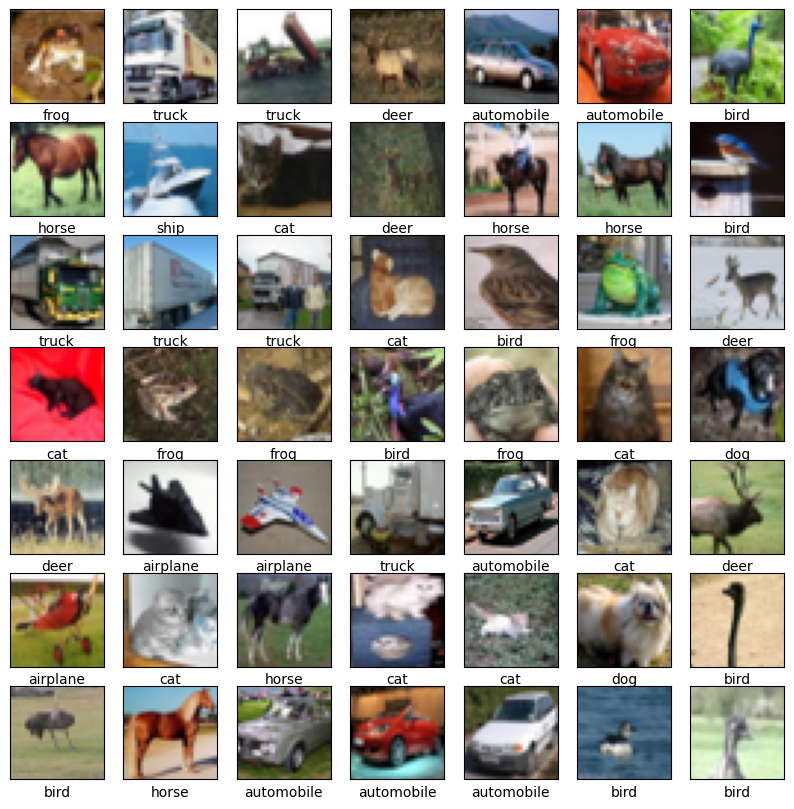

In [3]:

plt.figure(figsize=(10,10))
for i in range(49):
    plt.subplot(7,7,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(True)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()


# 4. Construir el Modelo

In [4]:

model = models.Sequential([
  layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(10)
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Compilar y Entrenar el Modelo

In [5]:

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.4392 - loss: 1.5361 - val_accuracy: 0.5532 - val_loss: 1.2722
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5920 - loss: 1.1514 - val_accuracy: 0.6128 - val_loss: 1.0947
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6511 - loss: 0.9952 - val_accuracy: 0.6535 - val_loss: 0.9776
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6834 - loss: 0.9004 - val_accuracy: 0.6814 - val_loss: 0.9203
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7108 - loss: 0.8278 - val_accuracy: 0.6914 - val_loss: 0.8910
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7315 - loss: 0.7717 - val_accuracy: 0.6954 - val_loss: 0.8826
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7483 - loss: 0.7248 - val_accuracy: 0.6965 - val_loss: 0.8797
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7623 - loss: 0.6764 

# 6. Evaluar el Modelo

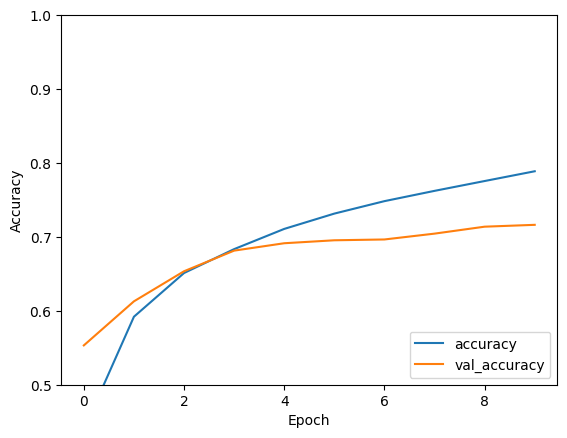

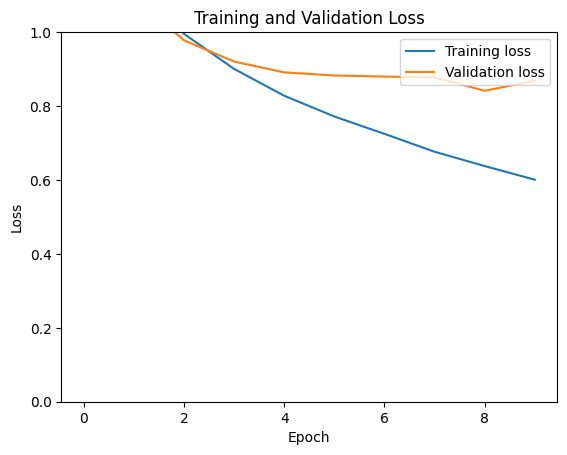

313/313 - 1s - 3ms/step - accuracy: 0.7163 - loss: 0.8683
presición sobre el set de datos de prueba: 0.7163000106811523


In [8]:

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])  # Ajuste el rango según sea necesario para su conjunto de datos y modelo
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print("presición sobre el set de datos de prueba:", test_acc)


# 7. Hacer Predicciones con el Modelo

In [6]:

probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_images)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


# 8. Calcular la Matriz de Confusión

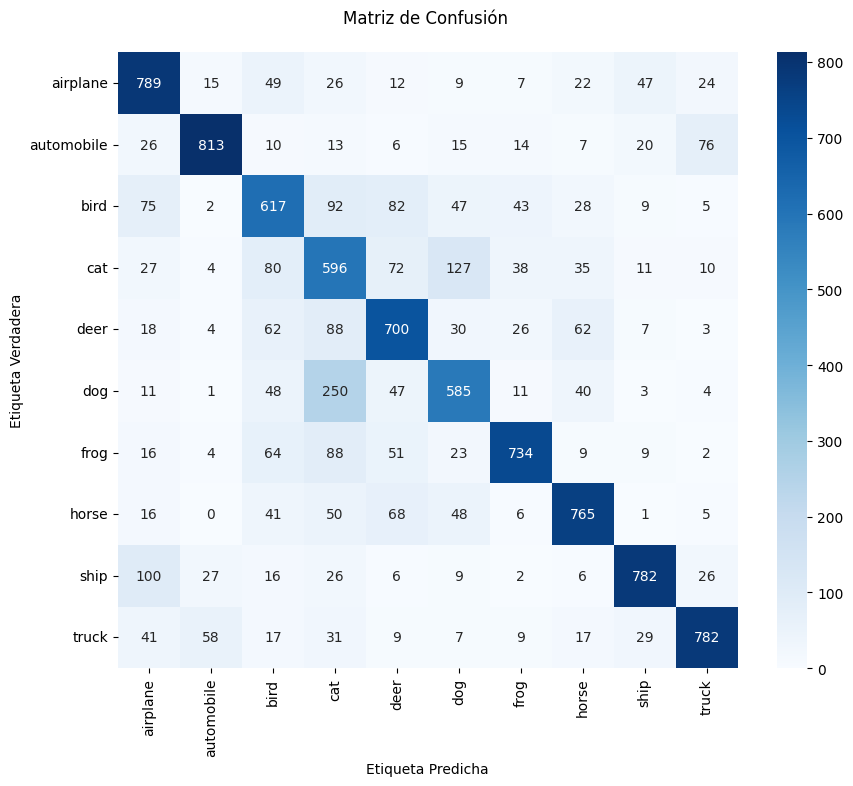

In [7]:

pred_labels = np.argmax(predictions, axis=1)
true_labels = test_labels.flatten()

conf_matrix = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")  # Uso de la paleta de colores azules
plt.title('Matriz de Confusión \n')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()


# Visualización de Data Augmentation y Entrenamiento de Modelo en CIFAR-10


Este notebook extiende el ejemplo de Data Augmentation para visualizar no solo las imágenes transformadas sino también las originales para comparar. Además, se completa con el entrenamiento del modelo utilizando las imágenes aumentadas.
    

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt


## Cargar y Preprocesar el Conjunto de Datos

In [ ]:

# Cargar el conjunto de datos CIFAR-10
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Normalizar las imágenes a un rango de 0 a 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0


## Configurar el Generador de Data Augmentation y Visualizar Imágenes

In [ ]:

# Configurar el generador de Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

# Visualizar imágenes originales y sus versiones aumentadas
def plot_images(images_arr, n_images=10):
    fig, axes = plt.subplots(2, n_images, figsize=(20, 4))
    axes = axes.flatten()

    for i in range(n_images):
        img = images_arr[i]
        axes[i].imshow(img)
        axes[i].axis('off')

        augmented_img = next(datagen.flow(np.expand_dims(img, 0)))[0]
        axes[i + n_images].imshow(augmented_img)
        axes[i + n_images].axis('off')

    plt.tight_layout()
    plt.show()

plot_images(train_images)


## Definir y Entrenar el Modelo

In [ ]:

# Definir la arquitectura del modelo
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo con el generador de Data Augmentation
history = model.fit(datagen.flow(train_images, train_labels, batch_size=32),
                    epochs=20,
                    validation_data=(test_images, test_labels))


In [ ]:
# prompt: Agregar reporte de clasificación y matriz de confusión, de la misma forma agregar curva ROC.

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

# ... (previous code remains the same)
"""
# Definir la arquitectura del modelo
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo con el generador de Data Augmentation
history = model.fit(datagen.flow(train_images, train_labels, batch_size=32),
                    epochs=10,
                    validation_data=(test_images, test_labels))


# Evaluar el modelo y obtener predicciones
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generar reporte de clasificación
print(classification_report(test_labels, y_pred_classes))"""

# Generar matriz de confusión
cm = confusion_matrix(test_labels, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Calcular y visualizar la curva ROC (para cada clase)
# Se necesita convertir las etiquetas a one-hot para la curva ROC multi-clase.
y_test_onehot = tf.keras.utils.to_categorical(test_labels, num_classes=10)


fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(10):
  fpr[i], tpr[i], _ = roc_curve(y_test_onehot[:, i], y_pred[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure()
for i in range(10):
  plt.plot(fpr[i], tpr[i], label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC (Multi-clase)')
plt.legend(loc="lower right")
plt.show()


## Ejercicios para Resolver en Clase
Cada ejercicio debe incluir:
1. Preprocesamiento de datos
2. Definición de la arquitectura del modelo
3. Compilación y entrenamiento
4. Evaluación y métricas de rendimiento


### Ejercicio 1: Clasificación de MNIST

#### Preprocesamiento de datos

In [ ]:
from tensorflow.keras.utils import to_categorical
import tensorflow_datasets as tfds

# Cargar MNIST
ds_train1, ds_test1 = tfds.load('mnist', split=['train','test'], as_supervised=True)

def preprocess_mnist(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=10)
    return image, label

batch_size = 64
ds_train1 = ds_train1.map(preprocess_mnist).shuffle(1000).batch(batch_size)
ds_test1 = ds_test1.map(preprocess_mnist).batch(batch_size)



In [ ]:
ds_test1.s

#### Definición de la arquitectura del modelo

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
model1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model1.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


#### Compilación y Entrenamiento

In [ ]:
# Compilar\model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Entrenar
epochs1 = 10
history1 = model1.fit(ds_train1, epochs=epochs1, validation_data=ds_test1)

#### Evaluación y métricas

In [ ]:
# Mostrar la matriz de confusión con valores numéricos en cada celda
import numpy as np

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')  # Mostrar heatmap
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta verdadera')

# Recorremos cada celda para escribir el valor
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, int(v), ha='center', va='center')  # Escribir el conteo

plt.tight_layout()
plt.show()

### Ejercicio 2: Clasificación de Fashion MNIST

#### Preprocesamiento de datos

In [ ]:
# Cargar Fashion MNIST
ds_train2, ds_test2 = tfds.load('fashion_mnist', split=['train','test'], as_supervised=True)

def preprocess_fashion(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=10)
    return image, label

ds_train2 = ds_train2.map(preprocess_fashion).shuffle(1000).batch(batch_size)
ds_test2 = ds_test2.map(preprocess_fashion).batch(batch_size)

#### Definición de la arquitectura del modelo

In [ ]:
# COMPLETAR: Definir modelo CNN para Fashion MNIST (variable model2)

#### Compilación y Entrenamiento

In [ ]:
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
epochs2 = 10
history2 = model2.fit(ds_train2, epochs=epochs2, validation_data=ds_test2)

#### Evaluación y métricas

In [ ]:
# Mostrar la matriz de confusión con valores numéricos en cada celda
import numpy as np

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')  # Mostrar heatmap
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta verdadera')

# Recorremos cada celda para escribir el valor
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, int(v), ha='center', va='center')  # Escribir el conteo

plt.tight_layout()
plt.show()